In [1]:
from datasets import load_dataset

from data_processing import _select_usable_examples, process_one_obj_one_band_train_heldout
from singleGP_model import fit_basic_gp
from evaluation_metrics import (
    evaluate_heldout_metrics,
    summarize_single_band_gp_class_metrics,
)

dset_plasticc = load_dataset(
    "MultimodalUniverse/plasticc",
    streaming=True,
    split="train",
).with_format("numpy")

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Single-band GP
This test aggregates single-band GP evaluation metrics by object class using object-weighted aggregation.

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/

        class  n_objects  n_objects_skipped_small_flux  min_object_flux_scale  \
0         AGN         27                             0               0.000001   
1          EB         24                             0               0.000001   
2          KN          9                             1               0.000001   
3     M-dwarf         39                             0               0.000001   
4         RRL          5                             0               0.000001   
5      SLSN-I         15                             0               0.000001   
6        SNII         95                             0               0.000001   
7        SNIa        182                             0               0.000001   
8   SNIa-91bg         13                             0               0.000001   
9       SNIax         13                             0               0.000001   
10      SNIbc         35                             0               0.000001   
11        TDE         42    

,class,n_objects,n_objects_skipped_small_flux,min_object_flux_scale,n_target_train_mean,n_target_train_std,n_target_train_median,n_target_train_min,n_target_train_max,n_target_train_p10,...,coverage_3sigma_std,z_mean_mean,z_mean_std,z_std_mean,z_std_std,ks_pit_mean,ks_pit_std,n_objects_zstd_n_test_ge_5,z_std_mean_n_test_ge_5,z_std_std_n_test_ge_5
0,AGN,27,0,0.000001,23.925926,10.244876,19.0,13,41,16.0,...,0.074211,0.066053,0.542859,1.116426,0.416876,0.342440,0.125568,24,1.139654,0.435277
1,EB,24,0,0.000001,31.416667,10.816333,41.0,14,41,17.6,...,0.112977,-0.056863,0.819696,1.448252,1.326105,0.396181,0.089952,23,1.484016,1.343248
2,KN,9,1,0.000001,17.777778,1.930905,17.0,15,20,15.0,...,0.000000,0.066111,0.360350,0.767729,0.376475,0.361714,0.097715,7,0.787137,0.398382
3,M-dwarf,39,0,0.000001,31.538462,10.807989,41.0,17,41,18.0,...,0.084064,0.145183,0.736402,1.158876,2.369522,0.355996,0.100999,39,1.158876,2.369522
4,RRL,5,0,0.000001,36.000000,10.000000,41.0,16,41,26.0,...,0.145455,-0.003392,0.627286,1.961734,0.917412,0.303117,0.105399,5,1.961734,0.917412
5,SLSN-I,15,0,0.000001,25.866667,10.800412,20.0,16,41,17.0,...,0.000000,-0.010036,0.262195,0.639174,0.351310,0.330981,0.097110,14,0.673784,0.338033
6,SNII,95,0,0.000001,24.715789,10.086639,20.0,15,41,16.4,...,0.033213,-0.032579,0.407833,0.724736,0.507659,0.355782,0.101167,90,0.741381,0.515559
7,SNIa,182,0,0.000001,27.373626,11.112460,20.0,15,41,16.1,...,0.062978,-0.125698,0.585290,0.758852,0.731251,0.356987,0.106581,174,0.737950,0.678123
8,SNIa-91bg,13,0,0.000001,20.461538,6.295485,19.0,16,41,16.2,...,0.000000,-0.079941,0.356289,0.514743,0.269819,0.395420,0.117004,11,0.584599,0.233042
9,SNIax,13,0,0.000001,30.923077,10.936611,41.0,16,41,19.0,...,0.024224,0.022483,0.372133,0.691737,0.229266,0.311812,0.108440,13,0.691737,0.229266


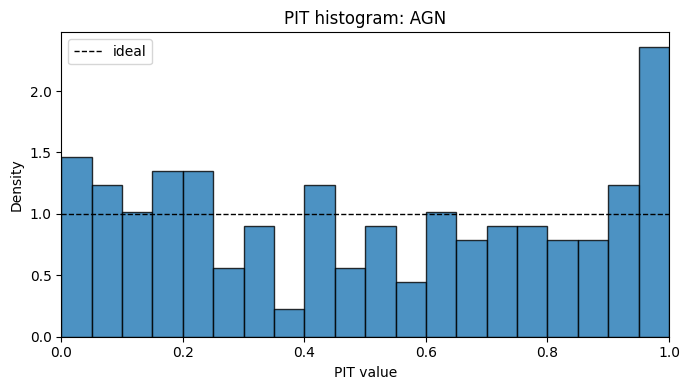

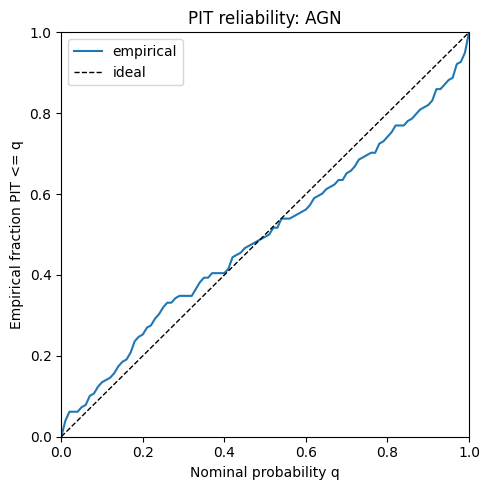

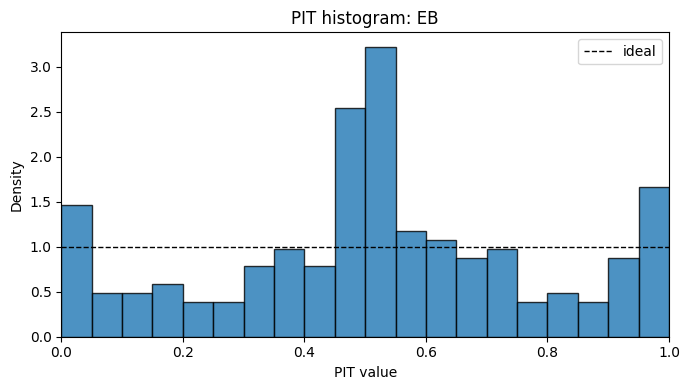

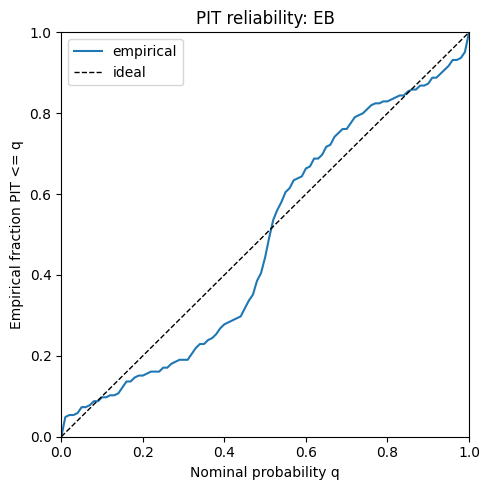

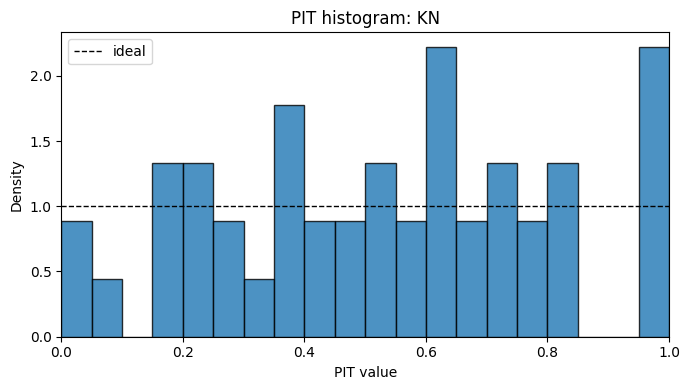

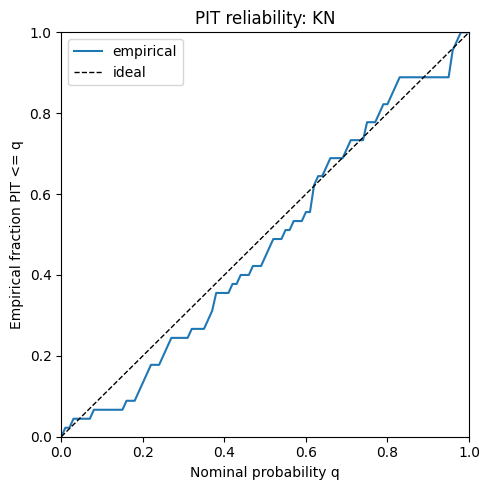

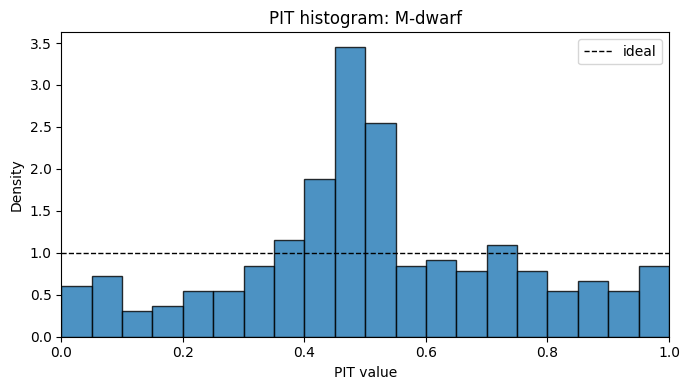

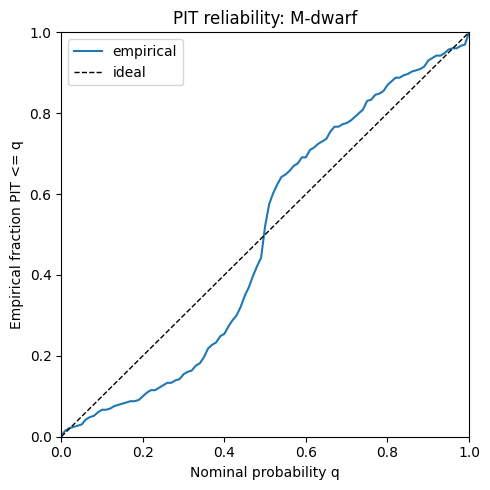

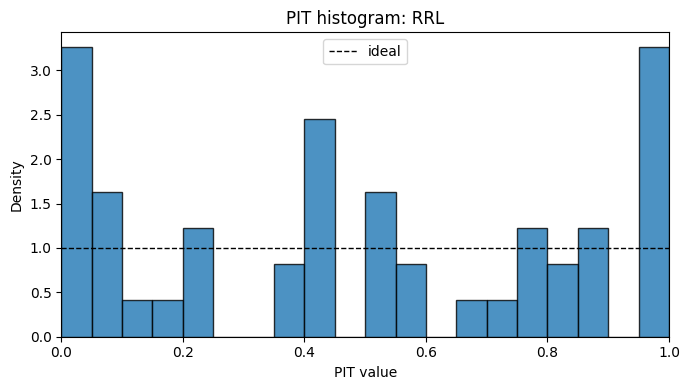

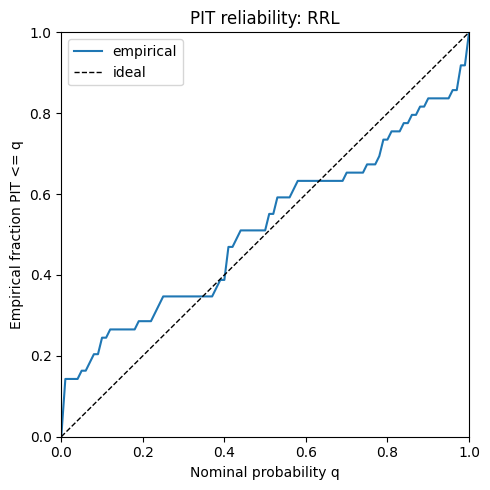

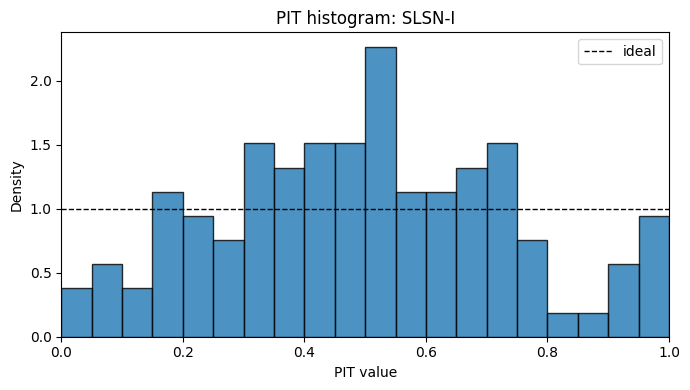

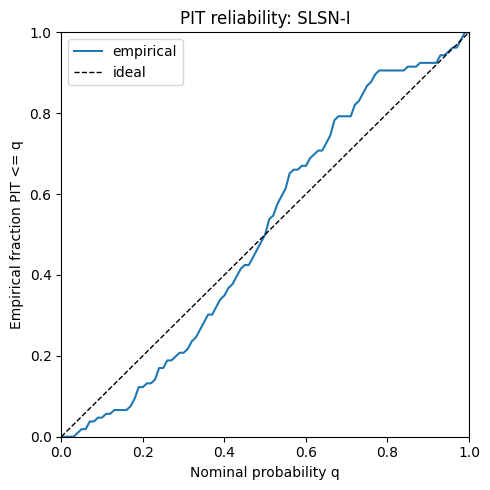

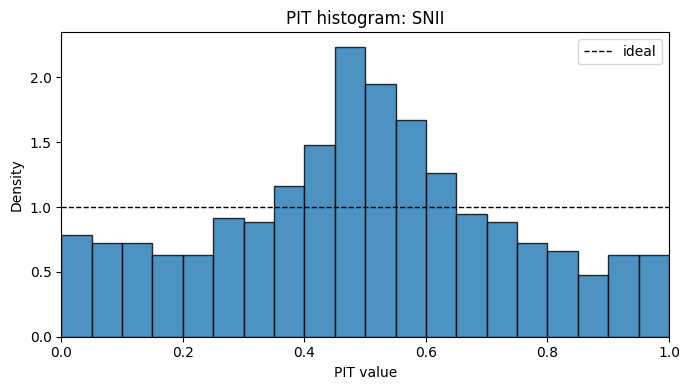

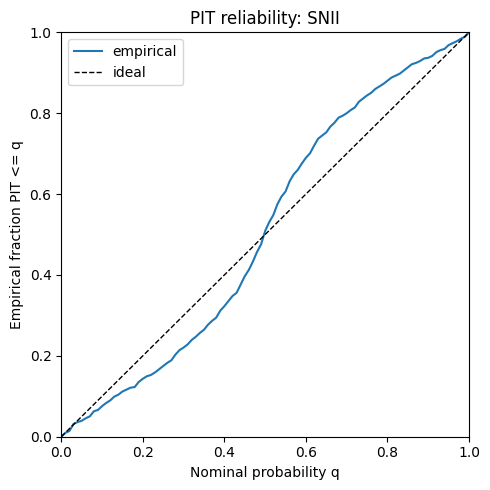

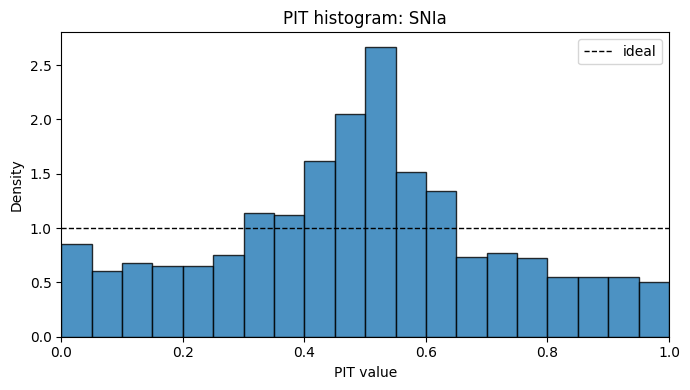

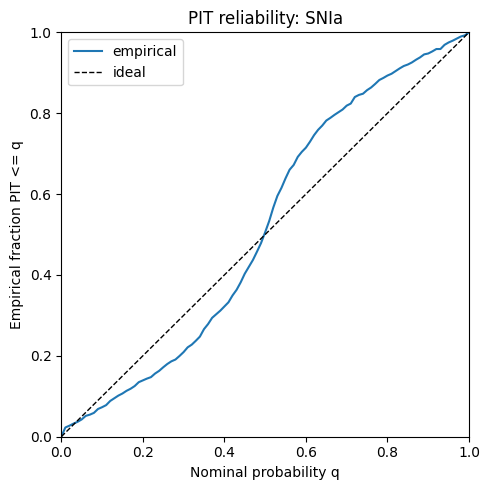

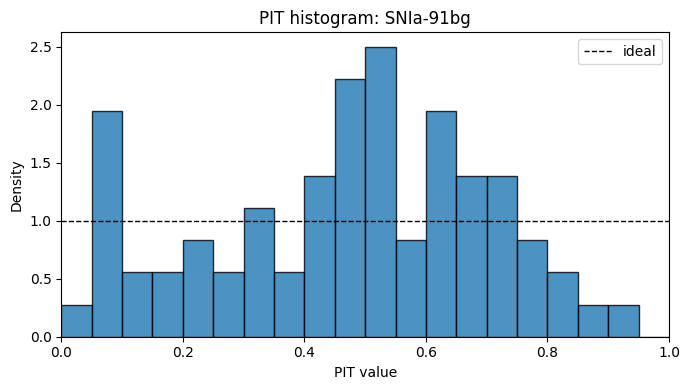

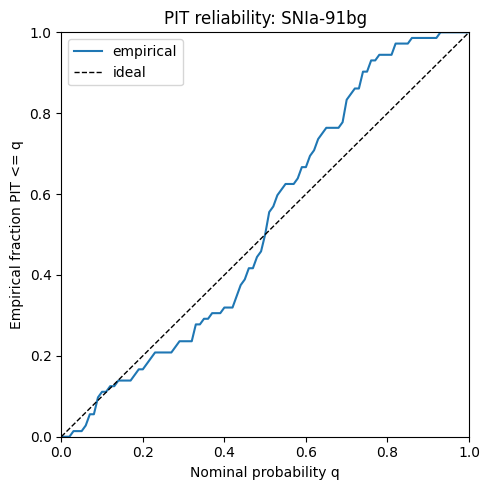

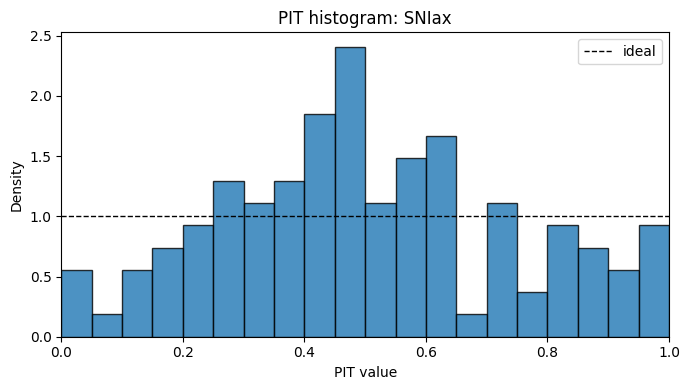

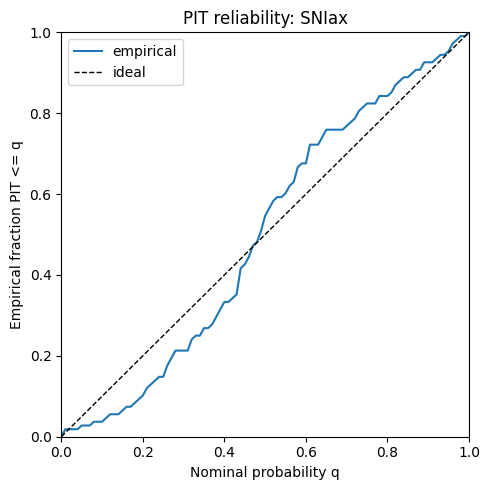

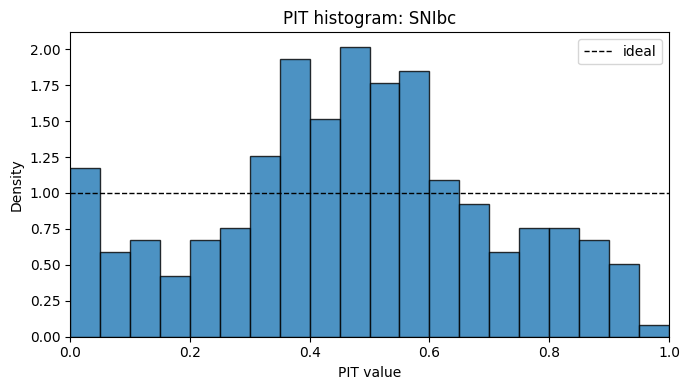

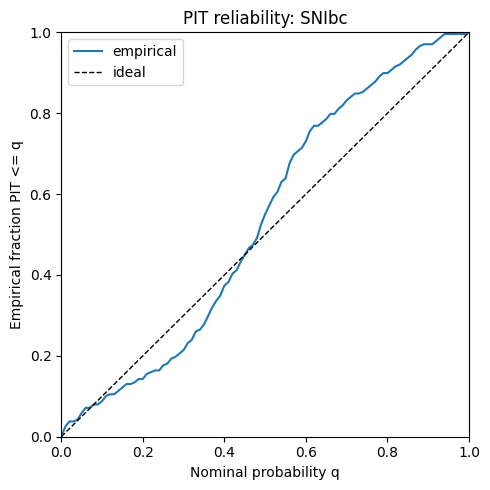

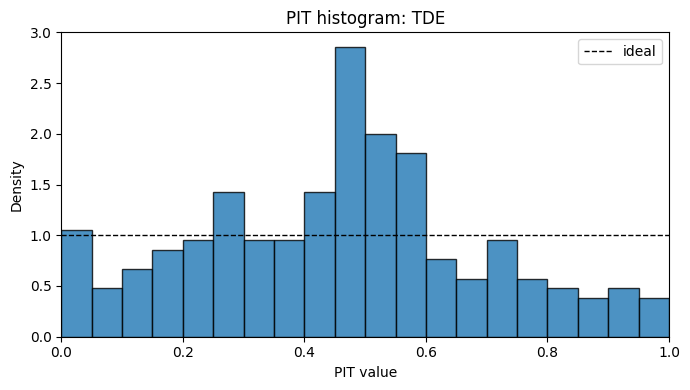

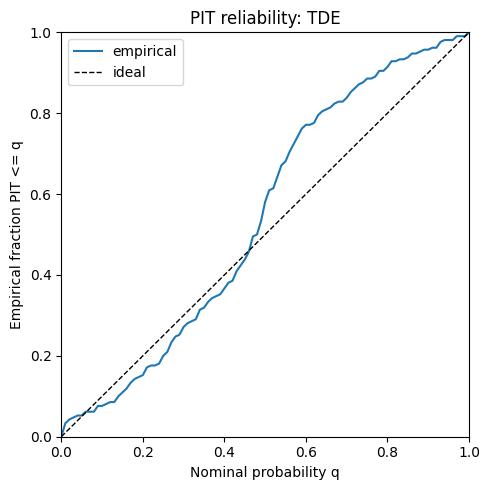

In [2]:
selected_examples, scanned_examples = _select_usable_examples(
    iter(dset_plasticc),
    target_band="r",
    n_objects=500,
    max_examples_to_scan=1000,
    min_points=8,
)

object_results = []

for object_idx, example in enumerate(selected_examples):
    train_data, heldout_data = process_one_obj_one_band_train_heldout(
        example,
        target_band="r",
        normalize_flux=True,
        min_points=8,
        heldout_fraction=0.2,
        min_train_points=5,
        min_heldout_points=1,
        random_state=object_idx,
        strategy="random",
        force_peak_in_train=True,
        peak_mode="absolute",
        peak_alignment="target_abs_peak",
        subtract_background=False,
        scale_mode="local_peak",
    )

    if train_data is None or heldout_data is None:
        continue

    gp = fit_basic_gp(train_data, kernel_type="matern")

    metrics = evaluate_heldout_metrics(
        gp,
        heldout_data,
        train_data=train_data,
        object_data=example,
    )

    metrics["obj_id"] = train_data["obj_id"]
    metrics["obj_type"] = train_data["obj_type"]
    object_results.append(metrics)

class_summary = summarize_single_band_gp_class_metrics(
    object_results,
    output_path="single_band_gp_class_summary.csv",
    print_table=True,
    plot_pit=True,
)

class_summary

Let's review the lightcurves of each class. Below shows the red-band lightcurves of 500 objects.

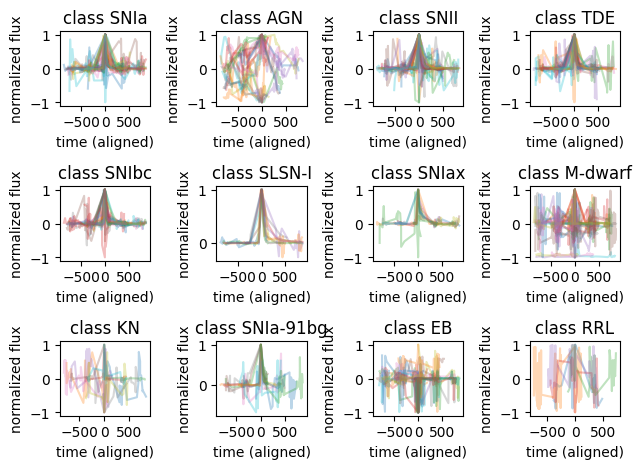

In [6]:
import numpy as np
import matplotlib.pyplot as plt
dset_iterator = iter(dset_plasticc)
curves = {}

for i, example in zip(range(500), dset_iterator):
    lc = example["lightcurve"]
    time = np.array(lc["time"])
    flux = np.array(lc["flux"])
    band = np.array(lc["band"])

    mask = (band == "r") & (time > 10000)

    t = time[mask]
    f = flux[mask]

    if len(t) < 5:
        continue
    t_peak = t[np.argmax(np.abs(f))]
    t = t - t_peak
    f = f / np.max(np.abs(f))

    obj_type = example["obj_type"]
    curves.setdefault(obj_type, []).append((t, f))

# plot the first 50 curves of each class
i = 0
for obj_type, data in curves.items():
    i += 1
    plt.subplot(3, 4, i)
    for t, f in data[:50]:
        plt.plot(t, f, alpha=0.3)

    plt.title(f"class {obj_type}")
    plt.xlabel("time (aligned)")
    plt.ylabel("normalized flux")
plt.tight_layout()
plt.show()

I notice that chaotic-looking curves often yield overconfident results, while single-GP trained on supernova-like curves, which typically has spike or peak in their features and flat regions away from the peak, is more likely to become underconfident.
I will average the flux values in the same bin. The result over all classes are then visualized below.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math

time_bins = np.linspace(-500, 500, 50)
bin_centers = (time_bins[:-1] + time_bins[1:]) / 2
n_bins = len(bin_centers)

curves = {}

for i, example in zip(range(3000), iter(dset_plasticc)):
    obj_type = str(example["obj_type"])
    obj_id = str(example.get("object_id", i))

    lc = example["lightcurve"]

    time = np.array(lc["time"])
    flux = np.array(lc["flux"])
    band = np.array(lc["band"])

    mask = time > 10000
    time = time[mask]
    flux = flux[mask]
    band = band[mask]

    if len(time) < 10:
        continue

    max_flux = np.quantile(np.abs(flux), 0.95)
    if max_flux <= 1e-3:
        continue

    flux_norm = flux / max_flux

    t_peak = time[np.argmax(np.abs(flux))]
    time_aligned = time - t_peak

    for b in np.unique(band):
        m = band == b
        t_b = time_aligned[m]
        f_b = flux_norm[m]

        digitized = np.digitize(t_b, time_bins)

        for k in range(1, len(time_bins)):
            bin_mask = digitized == k

            if np.any(bin_mask):
                mean_flux = np.mean(f_b[bin_mask])
                bin_idx = k - 1

                curves.setdefault(obj_type, {}) \
                      .setdefault(b, {}) \
                      .setdefault(obj_id, {}) \
                      .setdefault(bin_idx, []) \
                      .append(mean_flux)

In [12]:
class_band_mean_curves = {}

for obj_type, band_dict in curves.items():
    class_band_mean_curves[obj_type] = {}

    for b, object_dict in band_dict.items():
        object_curves = []

        for obj_id, bin_dict in object_dict.items():
            obj_curve = np.full(n_bins, np.nan)

            for bin_idx in range(n_bins):
                if bin_idx in bin_dict:
                    obj_curve[bin_idx] = np.mean(bin_dict[bin_idx])

            object_curves.append(obj_curve)

        object_curves = np.array(object_curves)
        band_mean_curve = np.nanmean(object_curves, axis=0)

        class_band_mean_curves[obj_type][b] = band_mean_curve

/var/folders/6n/52b69bhs4ts1df66shlc4gk40000gn/T/ipykernel_39192/4244028558.py:19: RuntimeWarning: Mean of empty slice
  band_mean_curve = np.nanmean(object_curves, axis=0)


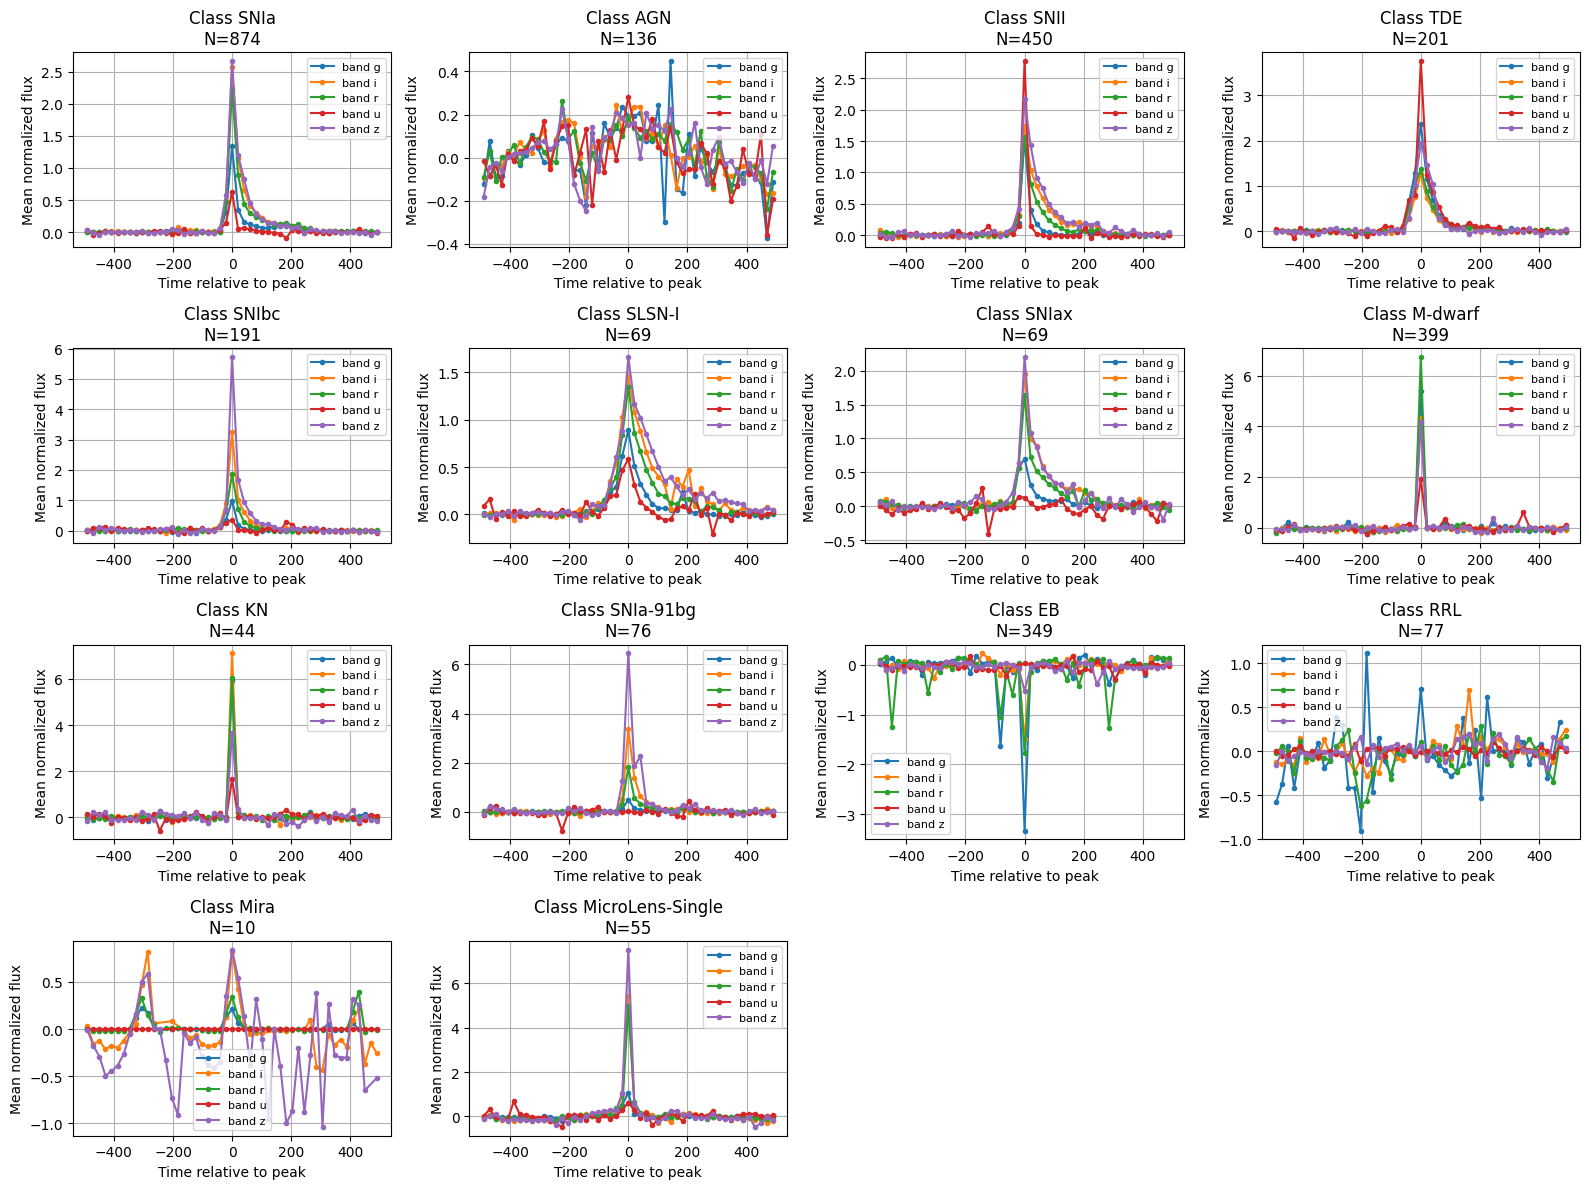

In [14]:
class_counts = {}

for obj_type, band_dict in curves.items():
    object_ids = set()

    for object_dict in band_dict.values():
        object_ids.update(object_dict.keys())

    class_counts[obj_type] = len(object_ids)

n_classes = len(class_band_mean_curves)
n_cols = 4
n_rows = math.ceil(n_classes / n_cols)

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, (obj_type, band_curves) in enumerate(class_band_mean_curves.items(), start=1):
    plt.subplot(n_rows, n_cols, i)

    for b, mean_flux in sorted(band_curves.items()):
        valid = ~np.isnan(mean_flux)
        plt.plot(
            bin_centers[valid],
            mean_flux[valid],
            marker="o",
            markersize=3,
            label=f"band {b}"
        )

    plt.title(f"Class {obj_type}\nN={class_counts[obj_type]}")
    plt.xlabel("Time relative to peak")
    plt.ylabel("Mean normalized flux")
    plt.grid(True)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()